# Tutorial: Extracting Q Factor Using Harminv (Meep)

This tutorial demonstrates how to extract the cavity **quality factor (Q)** using `harminv` in Meep.

---

## 1️⃣ Basic Idea

`harminv` analyzes the time-domain field signal at a point and fits it to decaying sinusoids:

$
E(t) \sim e^{-i\omega t} e^{-t/\tau}
$

From this, it extracts:

- Resonant frequency \( f \)
- Decay rate $\gamma$
- Quality factor  

The Q factor is defined as:

$
Q = -\frac{\omega}{2\gamma}
$

where:
- $\omega = 2\pi f $
- $\gamma$ is the decay rate
---

## 2️⃣ Add Harminv to Simulation

Place a field monitor at the cavity center:

```python
harminv_obj = mp.Harminv(
    mp.Ez,                    # field component
    mp.Vector3(0, 0),         # monitor position
    fcen,                     # center frequency
    df                        # frequency width
)

In [1]:
import meep as mp
import meep.adjoint as mpa
from meep.materials import Au, Ag 
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product, grad
import nlopt
from matplotlib import pyplot as plt
from matplotlib.patches import Circle
import time
import os
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd

In [2]:
dir_path = 'post-harm'
os.makedirs(dir_path, exist_ok=True)

In [3]:
mp.verbosity(1)
Air = mp.Medium(index=1)
Si = mp.Medium(index = 3.48)
resolution = 50 
dx = 0.9  #design_region_x_width = 1    
dy = 0.9  #design_region_y_width = 1   
pml_size = 0.8
air_size = 0.3
Sx = dx
Sy = dy + 2*pml_size + 2*air_size
cell_size = mp.Vector3(Sx, Sy)

# Mapping parameters
minimum_length = 0.01
eta_i = 0.5
eta_e = 0.55
eta_d = 1 - eta_e
filter_radius = mpa.get_conic_radius_from_eta_e(minimum_length, eta_e)
design_region_resolution = int(resolution)
pml_layers = [mp.PML(thickness=pml_size, direction=mp.Y)]

monitor_position = mp.Vector3(Sx/2 - pml_size - 0.1, 0, 0)
monitor_size1 = mp.Vector3(0, dy, 0)

# Design frequency
wavelengths = np.array([1.55])
frequencies = np.array([1 / 1.55])
fcen = 1. / 1.55
width = 0.2
fwidth = width * fcen
source_center = mp.Vector3(-Sx/2,0) 
src_size = dy + 2* air_size
source_size = mp.Vector3(0,src_size) 
src = mp.GaussianSource(frequency=fcen, fwidth=fwidth)
source = [mp.Source(src, component=mp.Ey, size=source_size, center=source_center)]
# Design weight

Nx = int(design_region_resolution * dx) + 1
Ny = int(design_region_resolution * dy) + 1
design = np.load("tut_data/data/final_design.npy")
design = design.reshape(Nx,Ny)
design_variables = mp.MaterialGrid(mp.Vector3(Nx, Ny), Air, Si,weights=design, grid_type="U_MEAN")
design_region = mpa.DesignRegion(
    design_variables,
    volume=mp.Volume(
        center=mp.Vector3(0, 0, 0),
        size=mp.Vector3(dx, dy, 0),
    ),
)



# Setting geometry
geometry = [   
    mp.Block(center=design_region.center, size=design_region.size, material=design_variables),
]



# Main simulation
sim = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    default_material=Air,
    resolution=resolution,
    k_point=mp.Vector3(),
    extra_materials=[Si],
) 

     block, center = (0,0,0)
          size (0.9,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)


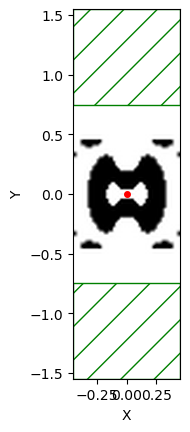

In [4]:
src = mp.GaussianSource(frequency=fcen, fwidth=1)
source = [mp.Source(src, component=mp.Ey, size=mp.Vector3(0,0), center=mp.Vector3(0,0))]
sim.change_sources(source)
sim.plot2D()
plt.show()
plt.close()


In [5]:
harminv_pt = mp.Vector3(0, 0)
h = mp.Harminv(mp.Ey, pt=harminv_pt, fcen=fcen, df=1)

# 執行模擬直到模態衰減
sim.run(mp.after_sources(h), until=2000)

# 擷取結果


-----------
Initializing structure...
time for choose_chunkdivision = 0.000103951 s
Working in 2D dimensions.
Computational cell is 0.9 x 3.1 x 0 with resolution 50
     block, center = (0,0,0)
          size (0.9,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
time for set_epsilon = 0.024502 s
-----------


FloatProgress(value=0.0, description='0% done ', max=2000.0)

Meep progress: 812.27/2000.0 = 40.6% done in 4.0s, 5.8s to go
on time step 81284 (time=812.84), 4.92103e-05 s/step
Meep progress: 1624.63/2000.0 = 81.2% done in 8.0s, 1.8s to go
on time step 162538 (time=1625.38), 4.92285e-05 s/step
harminv0:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv0:, 0.6455725718460472, -3.6510930093606316e-09, 88408124.66170205, 10.626593986723707, -1.2595999961249007+10.551677952270653i, 3.2286562435194505e-11+0.0i
harminv0:, 0.9377921508393943, -3.1282932593833468e-06, 149888.78488717088, 0.46531642961357395, 0.16136151764910106-0.4364422530991964i, 7.173517172673247e-10+0.0i
harminv0:, 1.0512809560358645, -2.694517874436105e-05, 19507.774767607938, 0.5431538932492525, 0.042295043862812014+0.5415046454246382i, 3.400529454242981e-10+0.0i
run 0 finished at t = 2000.0 (200000 timesteps)


In [6]:
data = [
    {
        "frequency": mode.freq,
        "decay": mode.decay,
        "Q": mode.Q,
        "abs_amplitude": abs(mode.amp),
        "amplitude": mode.amp,
        "error": mode.err,
    }
    for mode in h.modes  # 過濾低 Q 或雜訊模態
]

df = pd.DataFrame(data)
df.to_csv(f"{dir_path}/harminv_qfactor.csv", index=False)
print(df)

   frequency         decay             Q  abs_amplitude            amplitude  \
0   0.645573 -3.651093e-09  8.840812e+07      10.626594 -1.259600+10.551678j   
1   0.937792 -3.128293e-06  1.498888e+05       0.465316  0.161362- 0.436442j   
2   1.051281 -2.694518e-05  1.950777e+04       0.543154  0.042295+ 0.541505j   

                                            error  
0  3.228656e-11+0.000000e+                    00j  
1  7.173517e-10+0.000000e+                    00j  
2  3.400529e-10+0.000000e+                    00j  
